# 01_3 — Relationship Analysis / تحليل العلاقات

## الهدف | Objective

هذا الدفتر يركز على **العلاقات بين المتغيرات** في بيانات الطلاب، وليس فقط توزيع كل متغير بشكل منفصل.

سنستخدم:
- Scatter Plots لرؤية شكل العلاقة بين متغيرين.
- Line Plots لمقارنة المتوسطات حسب المجموعات.
- Correlation Heatmap لرؤية العلاقات الخطية بشكل عام.
- Box Plots لمقارنة المتغيرات الرقمية بين مستويات `Burnout_Level`.

> **مهم | Important:** الارتباط (Correlation) لا يعني السببية (Causation). الرسومات تساعدنا على اكتشاف الأنماط، لكنها لا تثبت أن متغيرًا يسبب الآخر.


In [1]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (9, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load Dataset | تحميل البيانات

نقرأ ملف البيانات المنظف من مجلد `data/raw`.

We load the cleaned dataset from the `data/raw` directory.


In [2]:
DATA_PATH = Path("../data/raw/AI_SocialMedia_Student_Health_Dataset_clean.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("../../data/raw/AI_SocialMedia_Student_Health_Dataset_clean.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Update DATA_PATH with the correct CSV path."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (15000, 14)


,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Burnout_Level,Academic_Performance_Score,Academic_Failure_Risk
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90,4.05,Low,88.80,0
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94,4.65,Moderate,50.60,0
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75,5.28,Low,96.67,0
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38,3.66,Low,85.65,0
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04,3.25,Moderate,71.84,0


## 2. Quick Data Check | فحص سريع

نتأكد من الأعمدة وأن المتغيرات المطلوبة موجودة قبل رسم العلاقات.

We check the available columns before plotting the relationships.


In [3]:
print("Columns:")
for col in df.columns:
    print("-", col)

numeric_df = df.select_dtypes(include=np.number)

print(f"\nNumber of numerical features: {numeric_df.shape[1]}")


Columns:
- Student_ID
- Age
- Gender
- Education_Level
- Daily_Social_Media_Hours
- Daily_AI_Tool_Usage_Hours
- Sleep_Hours
- Physical_Activity_Hours
- Mental_Health_Score
- Physical_Health_Score
- Social_Isolation_Score
- Burnout_Level
- Academic_Performance_Score
- Academic_Failure_Risk

Number of numerical features: 10


## 3. Correlation Heatmap | خريطة الارتباط

توضح هذه الخريطة قوة واتجاه العلاقة الخطية بين المتغيرات الرقمية.

### كيف نقرأها؟ | How to read it

- `+1` → علاقة طردية قوية / strong positive relationship
- `0` → لا توجد علاقة خطية واضحة / little or no linear relationship
- `-1` → علاقة عكسية قوية / strong negative relationship


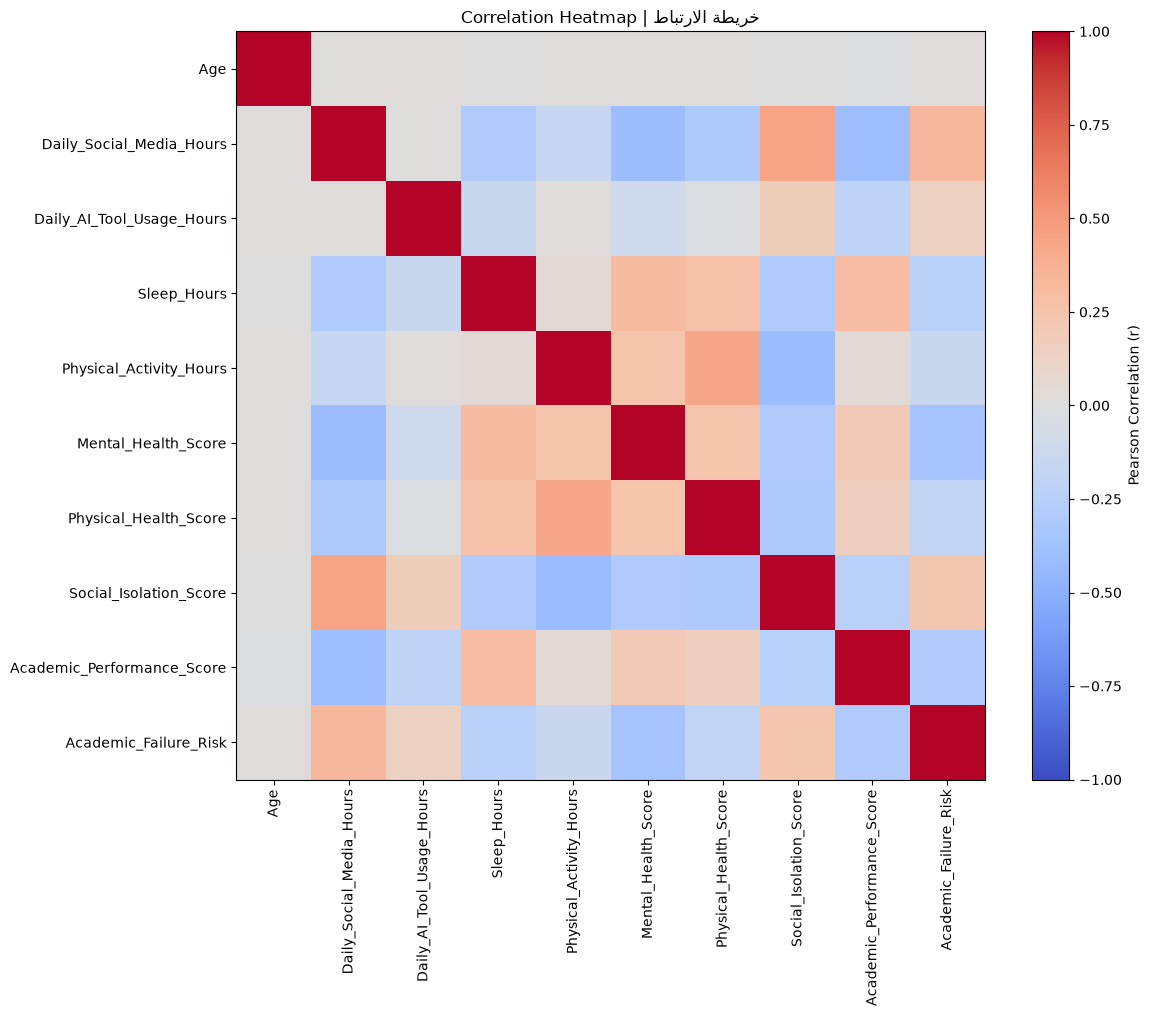

In [4]:
corr = numeric_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

ax.set_title("Correlation Heatmap | خريطة الارتباط")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson Correlation (r)")

plt.tight_layout()
plt.show()


## 4. Social Media vs Academic Performance

### ساعات السوشيال ميديا مقابل الأداء الأكاديمي

نستخدم Scatter Plot لرؤية شكل العلاقة بين المتغيرين، ونضيف خط اتجاه للمساعدة في فهم الاتجاه العام.

We use a Scatter Plot to visualize the relationship and add a trend line to make the overall direction easier to see.


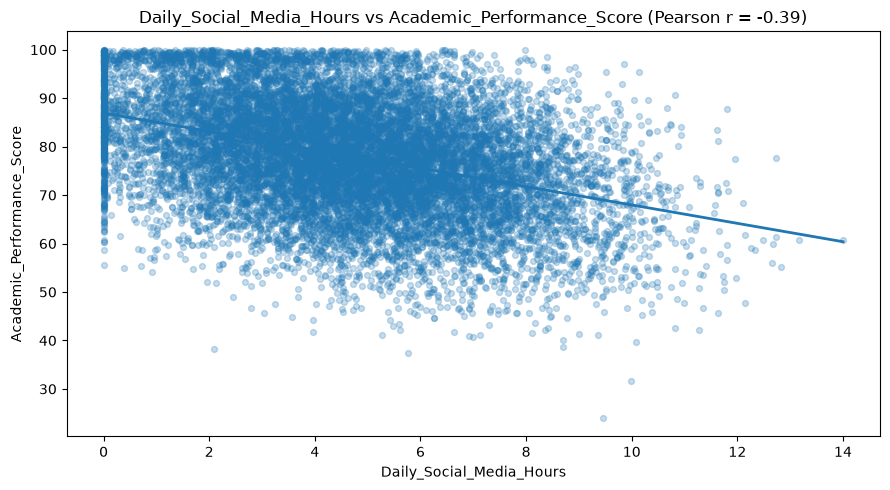

Pearson correlation: -0.394


In [5]:
x = "Daily_Social_Media_Hours"
y = "Academic_Performance_Score"

if x in df.columns and y in df.columns:
    temp = df[[x, y]].dropna()
    r = temp[x].corr(temp[y])

    fig, ax = plt.subplots()
    ax.scatter(temp[x], temp[y], alpha=0.25, s=18)

    z = np.polyfit(temp[x], temp[y], 1)
    line_x = np.linspace(temp[x].min(), temp[x].max(), 100)
    ax.plot(line_x, np.polyval(z, line_x), linewidth=2)

    ax.set_title(f"Daily_Social_Media_Hours vs Academic_Performance_Score (Pearson r = {r:.2f})")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation: {r:.3f}")
else:
    print("Required columns were not found.")


### Interpretation | التفسير

إذا كان خط الاتجاه نازلًا، فهذا يعني وجود **علاقة عكسية**: كلما زادت ساعات السوشيال ميديا، يميل الأداء الأكاديمي إلى الانخفاض.

If the trend line slopes downward, there is a **negative relationship**: higher social media usage tends to be associated with lower academic performance.

هذا لا يعني أن السوشيال ميديا تسبب انخفاض الأداء بشكل مباشر.


## 5. Social Media vs Mental Health

### ساعات السوشيال ميديا مقابل الصحة النفسية

نستخدم Scatter Plot لرؤية شكل العلاقة بين المتغيرين، ونضيف خط اتجاه للمساعدة في فهم الاتجاه العام.

We use a Scatter Plot to visualize the relationship and add a trend line to make the overall direction easier to see.


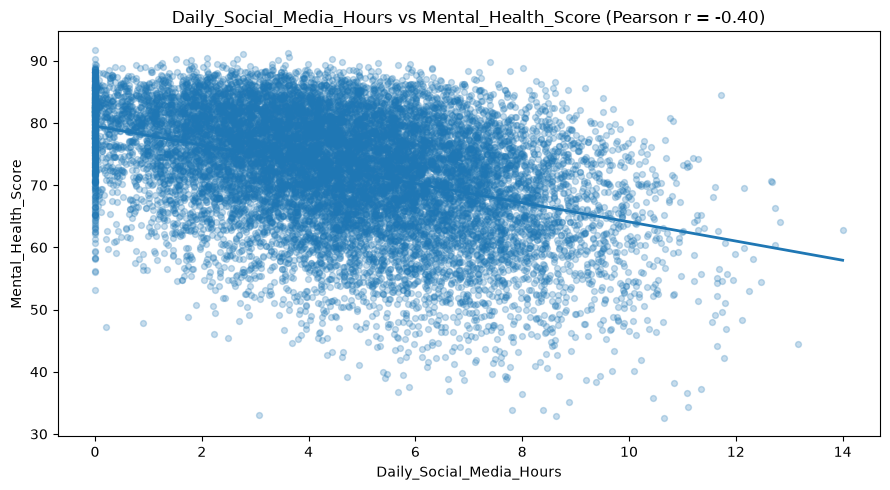

Pearson correlation: -0.400


In [6]:
x = "Daily_Social_Media_Hours"
y = "Mental_Health_Score"

if x in df.columns and y in df.columns:
    temp = df[[x, y]].dropna()
    r = temp[x].corr(temp[y])

    fig, ax = plt.subplots()
    ax.scatter(temp[x], temp[y], alpha=0.25, s=18)

    z = np.polyfit(temp[x], temp[y], 1)
    line_x = np.linspace(temp[x].min(), temp[x].max(), 100)
    ax.plot(line_x, np.polyval(z, line_x), linewidth=2)

    ax.set_title(f"Daily_Social_Media_Hours vs Mental_Health_Score (Pearson r = {r:.2f})")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation: {r:.3f}")
else:
    print("Required columns were not found.")


### Interpretation | التفسير

إذا كان الاتجاه نازلًا، فهذا يعني أن الطلاب الذين يستخدمون السوشيال ميديا لساعات أكثر يميلون إلى تسجيل درجات Mental Health أقل.

A downward trend suggests that higher social media usage is associated with lower mental health scores.


## 6. Social Media vs Social Isolation

### ساعات السوشيال ميديا مقابل العزلة الاجتماعية

نستخدم Scatter Plot لرؤية شكل العلاقة بين المتغيرين، ونضيف خط اتجاه للمساعدة في فهم الاتجاه العام.

We use a Scatter Plot to visualize the relationship and add a trend line to make the overall direction easier to see.


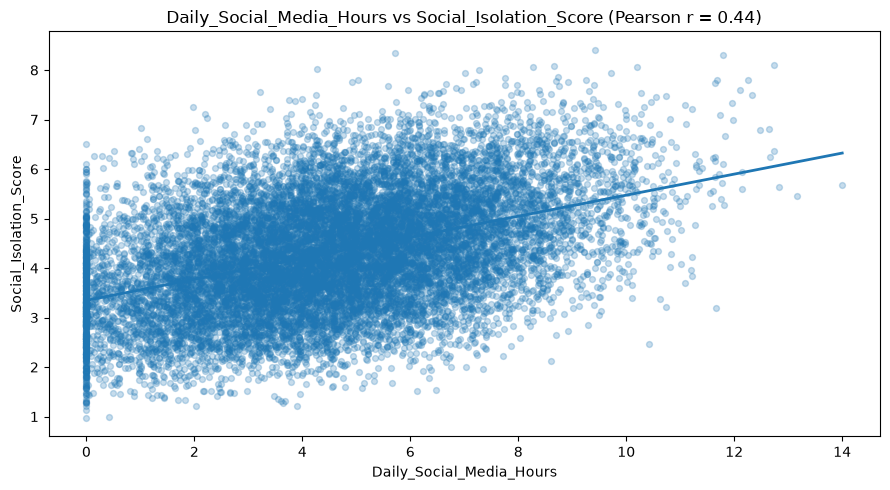

Pearson correlation: 0.439


In [7]:
x = "Daily_Social_Media_Hours"
y = "Social_Isolation_Score"

if x in df.columns and y in df.columns:
    temp = df[[x, y]].dropna()
    r = temp[x].corr(temp[y])

    fig, ax = plt.subplots()
    ax.scatter(temp[x], temp[y], alpha=0.25, s=18)

    z = np.polyfit(temp[x], temp[y], 1)
    line_x = np.linspace(temp[x].min(), temp[x].max(), 100)
    ax.plot(line_x, np.polyval(z, line_x), linewidth=2)

    ax.set_title(f"Daily_Social_Media_Hours vs Social_Isolation_Score (Pearson r = {r:.2f})")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation: {r:.3f}")
else:
    print("Required columns were not found.")


### Interpretation | التفسير

إذا كان خط الاتجاه صاعدًا، فهذا يشير إلى علاقة طردية: زيادة استخدام السوشيال ميديا ترتبط بزيادة `Social_Isolation_Score`.

An upward trend suggests a positive relationship between social media usage and social isolation.


## 7. Mental Health vs Academic Performance

### الصحة النفسية مقابل الأداء الأكاديمي

نستخدم Scatter Plot لرؤية شكل العلاقة بين المتغيرين، ونضيف خط اتجاه للمساعدة في فهم الاتجاه العام.

We use a Scatter Plot to visualize the relationship and add a trend line to make the overall direction easier to see.


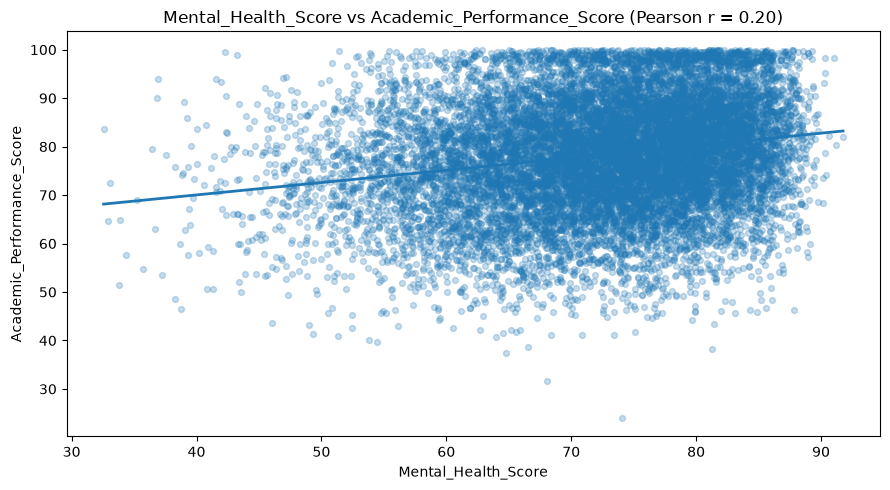

Pearson correlation: 0.204


In [8]:
x = "Mental_Health_Score"
y = "Academic_Performance_Score"

if x in df.columns and y in df.columns:
    temp = df[[x, y]].dropna()
    r = temp[x].corr(temp[y])

    fig, ax = plt.subplots()
    ax.scatter(temp[x], temp[y], alpha=0.25, s=18)

    z = np.polyfit(temp[x], temp[y], 1)
    line_x = np.linspace(temp[x].min(), temp[x].max(), 100)
    ax.plot(line_x, np.polyval(z, line_x), linewidth=2)

    ax.set_title(f"Mental_Health_Score vs Academic_Performance_Score (Pearson r = {r:.2f})")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation: {r:.3f}")
else:
    print("Required columns were not found.")


### Interpretation | التفسير

إذا كان الاتجاه صاعدًا، فهذا يعني أن درجات الصحة النفسية الأعلى ترتبط عادةً بأداء أكاديمي أعلى.

An upward trend suggests that higher mental health scores are associated with better academic performance.


## 8. Physical Activity vs Mental Health

### النشاط البدني مقابل الصحة النفسية

نستخدم Scatter Plot لرؤية شكل العلاقة بين المتغيرين، ونضيف خط اتجاه للمساعدة في فهم الاتجاه العام.

We use a Scatter Plot to visualize the relationship and add a trend line to make the overall direction easier to see.


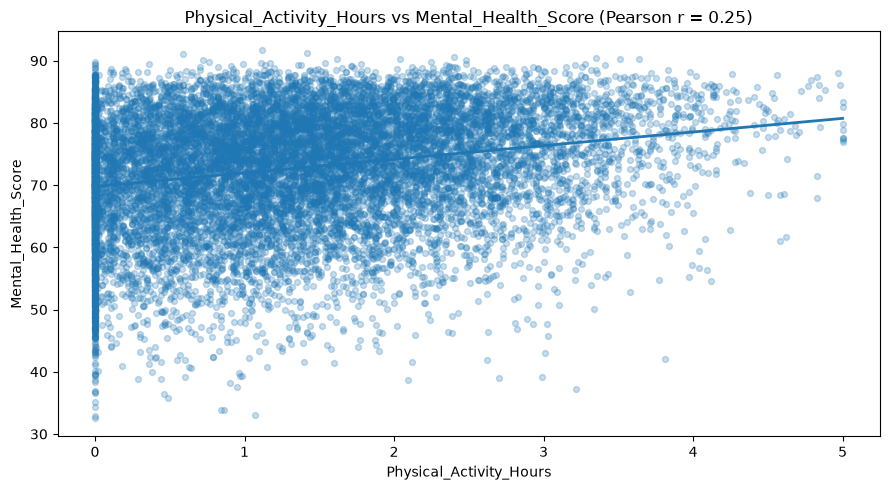

Pearson correlation: 0.246


In [9]:
x = "Physical_Activity_Hours"
y = "Mental_Health_Score"

if x in df.columns and y in df.columns:
    temp = df[[x, y]].dropna()
    r = temp[x].corr(temp[y])

    fig, ax = plt.subplots()
    ax.scatter(temp[x], temp[y], alpha=0.25, s=18)

    z = np.polyfit(temp[x], temp[y], 1)
    line_x = np.linspace(temp[x].min(), temp[x].max(), 100)
    ax.plot(line_x, np.polyval(z, line_x), linewidth=2)

    ax.set_title(f"Physical_Activity_Hours vs Mental_Health_Score (Pearson r = {r:.2f})")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation: {r:.3f}")
else:
    print("Required columns were not found.")


## 9. Physical Activity vs Physical Health

### النشاط البدني مقابل الصحة الجسدية

نستخدم Scatter Plot لرؤية شكل العلاقة بين المتغيرين، ونضيف خط اتجاه للمساعدة في فهم الاتجاه العام.

We use a Scatter Plot to visualize the relationship and add a trend line to make the overall direction easier to see.


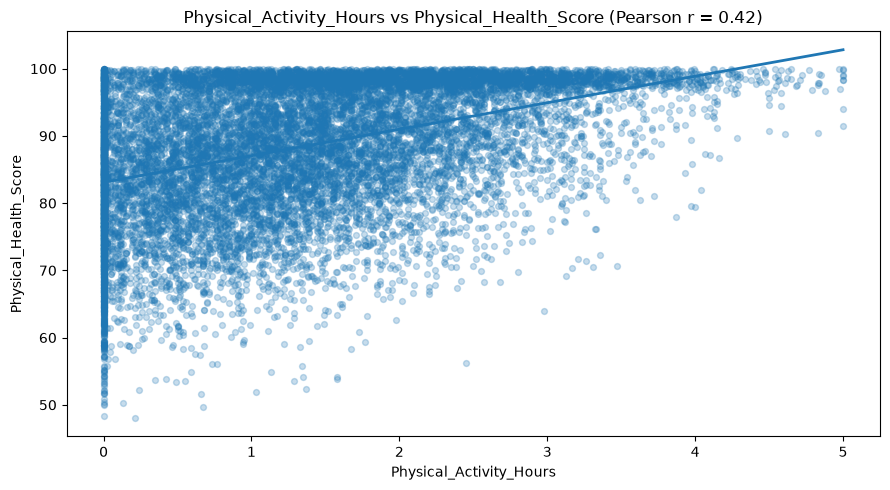

Pearson correlation: 0.423


In [10]:
x = "Physical_Activity_Hours"
y = "Physical_Health_Score"

if x in df.columns and y in df.columns:
    temp = df[[x, y]].dropna()
    r = temp[x].corr(temp[y])

    fig, ax = plt.subplots()
    ax.scatter(temp[x], temp[y], alpha=0.25, s=18)

    z = np.polyfit(temp[x], temp[y], 1)
    line_x = np.linspace(temp[x].min(), temp[x].max(), 100)
    ax.plot(line_x, np.polyval(z, line_x), linewidth=2)

    ax.set_title(f"Physical_Activity_Hours vs Physical_Health_Score (Pearson r = {r:.2f})")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation: {r:.3f}")
else:
    print("Required columns were not found.")


## 10. Sleep Hours vs Mental Health — Line Plot

### ساعات النوم مقابل الصحة النفسية

بدل أن نعرض كل نقطة، نستخدم متوسط `Mental_Health_Score` لكل قيمة من قيم ساعات النوم حتى يظهر الاتجاه بشكل أوضح.

Instead of plotting every individual observation, we plot the average mental health score for each sleep-hour value.


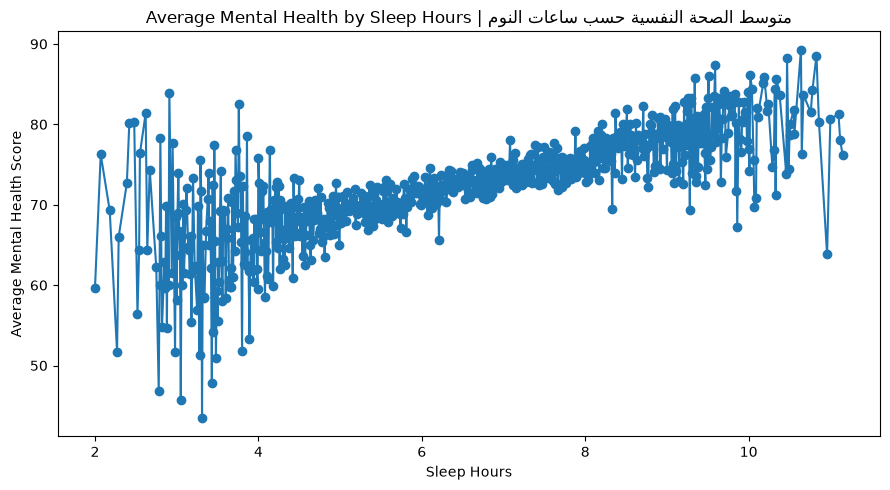

In [11]:
x = "Sleep_Hours"
y = "Mental_Health_Score"

if x in df.columns and y in df.columns:
    temp = df[[x, y]].dropna().copy()
    grouped = temp.groupby(x, as_index=False)[y].mean()

    fig, ax = plt.subplots()
    ax.plot(grouped[x], grouped[y], marker="o")

    ax.set_title(
        "Average Mental Health by Sleep Hours | "
        "متوسط الصحة النفسية حسب ساعات النوم"
    )
    ax.set_xlabel("Sleep Hours")
    ax.set_ylabel("Average Mental Health Score")

    plt.tight_layout()
    plt.show()


### Interpretation | التفسير

راقب شكل الخط: هل ترتفع الصحة النفسية مع النوم؟ وهل يوجد نطاق معين من ساعات النوم يعطي متوسطًا أفضل؟

The line helps us see whether mental health tends to change across different sleep durations.


## 11. Burnout Level vs Academic Performance

### مستوى الاحتراق النفسي مقابل الأداء الأكاديمي

لأن `Burnout_Level` متغير فئوي، فإن Box Plot مناسب لمقارنة الأداء الأكاديمي بين:

`Low → Moderate → High → Severe`

Because `Burnout_Level` is categorical, a Box Plot is useful for comparing academic performance across burnout levels.


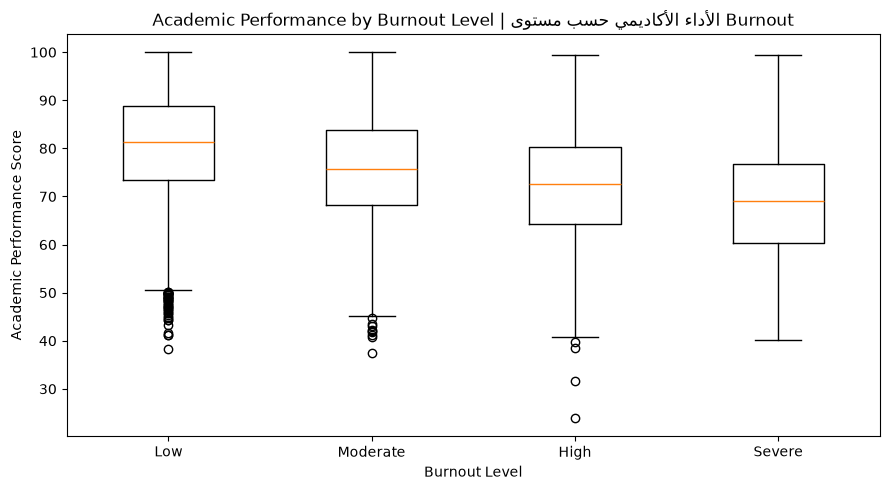

In [12]:
x = "Burnout_Level"
y = "Academic_Performance_Score"

if x in df.columns and y in df.columns:
    order = ["Low", "Moderate", "High", "Severe"]

    groups = [
        df.loc[df[x] == level, y].dropna()
        for level in order
    ]

    labels = [
        level for level, values in zip(order, groups)
        if len(values) > 0
    ]

    groups = [
        values for values in groups
        if len(values) > 0
    ]

    fig, ax = plt.subplots()
    ax.boxplot(groups, tick_labels=labels)

    ax.set_title(
        "Academic Performance by Burnout Level | "
        "الأداء الأكاديمي حسب مستوى Burnout"
    )
    ax.set_xlabel("Burnout Level")
    ax.set_ylabel("Academic Performance Score")

    plt.tight_layout()
    plt.show()


### Interpretation | التفسير

إذا لاحظنا أن Median الأداء الأكاديمي ينخفض كلما ارتفع مستوى الـBurnout، فهذا يشير إلى وجود علاقة بين ارتفاع الـBurnout وانخفاض الأداء الأكاديمي.

If the median academic performance decreases as burnout severity increases, this suggests an association between higher burnout and lower academic performance.


## 12. Burnout Level vs Mental Health

### مستوى الاحتراق النفسي مقابل الصحة النفسية


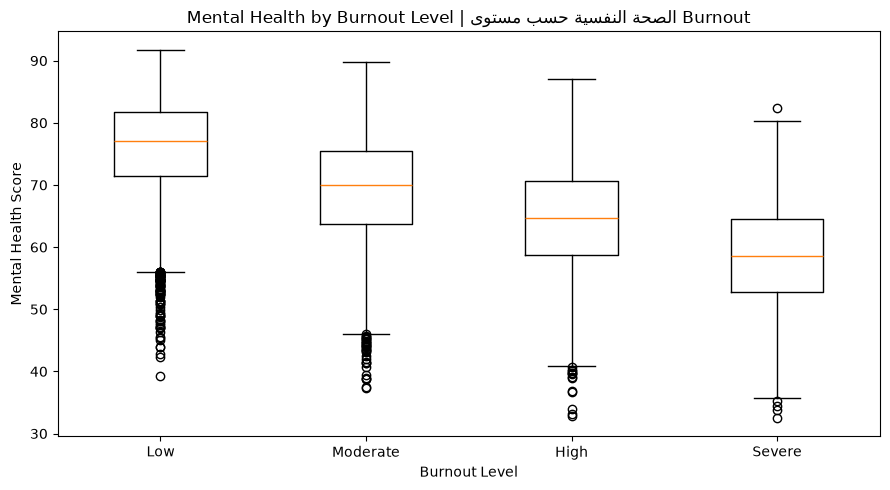

In [13]:
x = "Burnout_Level"
y = "Mental_Health_Score"

if x in df.columns and y in df.columns:
    order = ["Low", "Moderate", "High", "Severe"]

    groups = [
        df.loc[df[x] == level, y].dropna()
        for level in order
    ]

    labels = [
        level for level, values in zip(order, groups)
        if len(values) > 0
    ]

    groups = [
        values for values in groups
        if len(values) > 0
    ]

    fig, ax = plt.subplots()
    ax.boxplot(groups, tick_labels=labels)

    ax.set_title(
        "Mental Health by Burnout Level | "
        "الصحة النفسية حسب مستوى Burnout"
    )
    ax.set_xlabel("Burnout Level")
    ax.set_ylabel("Mental Health Score")

    plt.tight_layout()
    plt.show()


### Interpretation | التفسير

إذا انخفضت درجات `Mental_Health_Score` مع الانتقال من Low إلى Severe، فهذا يدل على وجود ارتباط بين ارتفاع مستوى الـBurnout وانخفاض الصحة النفسية.

If mental health scores decrease from Low to Severe burnout, this indicates an association between burnout severity and mental health.


## 13. Social Media vs Academic Failure Risk

### ساعات السوشيال ميديا مقابل خطر الفشل الأكاديمي

`Academic_Failure_Risk` متغير ثنائي:

- `0` = غير معرض للخطر
- `1` = معرض للخطر

سنقارن متوسط ساعات السوشيال ميديا بين المجموعتين.


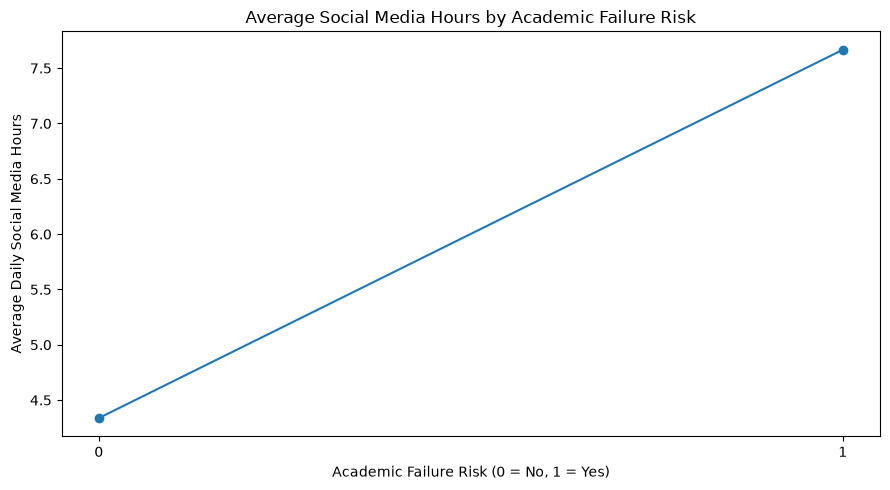

Academic_Failure_Risk
0    4.337782
1    7.666422
Name: Average Social Media Hours, dtype: float64

In [14]:
x = "Academic_Failure_Risk"
y = "Daily_Social_Media_Hours"

if x in df.columns and y in df.columns:
    grouped = df.groupby(x)[y].mean()

    fig, ax = plt.subplots()
    ax.plot(
        grouped.index.astype(str),
        grouped.values,
        marker="o"
    )

    ax.set_title(
        "Average Social Media Hours by Academic Failure Risk"
    )
    ax.set_xlabel(
        "Academic Failure Risk (0 = No, 1 = Yes)"
    )
    ax.set_ylabel(
        "Average Daily Social Media Hours"
    )

    plt.tight_layout()
    plt.show()

    display(grouped.rename("Average Social Media Hours"))


### Interpretation | التفسير

إذا كان متوسط استخدام السوشيال ميديا أعلى لدى المجموعة `1`، فهذا يعني أن الطلاب المصنفين كمعرضين لخطر الفشل لديهم استخدام أعلى في المتوسط.

If group `1` has higher average social media usage, students classified as at risk show higher usage on average.

لكن هذا لا يثبت السببية.


## 14. AI Tool Usage vs Academic Performance

### استخدام أدوات الذكاء الاصطناعي مقابل الأداء الأكاديمي

نستخدم Scatter Plot لرؤية شكل العلاقة بين المتغيرين، ونضيف خط اتجاه للمساعدة في فهم الاتجاه العام.

We use a Scatter Plot to visualize the relationship and add a trend line to make the overall direction easier to see.


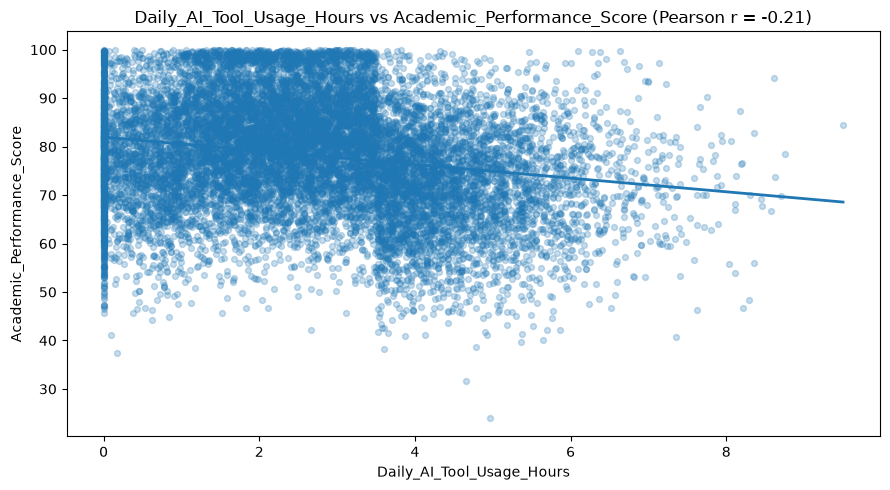

Pearson correlation: -0.205


In [15]:
x = "Daily_AI_Tool_Usage_Hours"
y = "Academic_Performance_Score"

if x in df.columns and y in df.columns:
    temp = df[[x, y]].dropna()
    r = temp[x].corr(temp[y])

    fig, ax = plt.subplots()
    ax.scatter(temp[x], temp[y], alpha=0.25, s=18)

    z = np.polyfit(temp[x], temp[y], 1)
    line_x = np.linspace(temp[x].min(), temp[x].max(), 100)
    ax.plot(line_x, np.polyval(z, line_x), linewidth=2)

    ax.set_title(f"Daily_AI_Tool_Usage_Hours vs Academic_Performance_Score (Pearson r = {r:.2f})")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation: {r:.3f}")
else:
    print("Required columns were not found.")


### Interpretation | التفسير

هذا الرسم يساعدنا على معرفة هل ساعات استخدام أدوات AI مرتبطة بالأداء الأكاديمي، وهل العلاقة تبدو إيجابية أو سلبية أو غير واضحة.

This plot helps us examine whether AI tool usage is associated with academic performance and whether the relationship appears positive, negative, or weak.


## 15. Relationship Summary | ملخص العلاقات

في النهاية نحسب Pearson correlation للعلاقات المهمة في المشروع.

We summarize the Pearson correlation for the main relationships.


In [16]:
important_pairs = [
    ("Daily_Social_Media_Hours", "Academic_Performance_Score"),
    ("Daily_Social_Media_Hours", "Mental_Health_Score"),
    ("Daily_Social_Media_Hours", "Social_Isolation_Score"),
    ("Mental_Health_Score", "Academic_Performance_Score"),
    ("Physical_Activity_Hours", "Mental_Health_Score"),
    ("Physical_Activity_Hours", "Physical_Health_Score"),
    ("Sleep_Hours", "Mental_Health_Score"),
    ("Daily_AI_Tool_Usage_Hours", "Academic_Performance_Score"),
]

rows = []

for a, b in important_pairs:
    if a in df.columns and b in df.columns:
        rows.append({
            "Feature 1": a,
            "Feature 2": b,
            "Pearson r": df[a].corr(df[b])
        })

relationship_summary = (
    pd.DataFrame(rows)
    .sort_values(
        "Pearson r",
        key=lambda s: s.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)

display(relationship_summary)


,Feature 1,Feature 2,Pearson r
0,Daily_Social_Media_Hours,Social_Isolation_Score,0.438550
1,Physical_Activity_Hours,Physical_Health_Score,0.422584
2,Daily_Social_Media_Hours,Mental_Health_Score,-0.399802
3,Daily_Social_Media_Hours,Academic_Performance_Score,-0.393920
4,Sleep_Hours,Mental_Health_Score,0.310587
5,Physical_Activity_Hours,Mental_Health_Score,0.245876
6,Daily_AI_Tool_Usage_Hours,Academic_Performance_Score,-0.205065
7,Mental_Health_Score,Academic_Performance_Score,0.204037


## Final Takeaway | الخلاصة النهائية

هذا الدفتر يحول التحليل من مجرد **"كيف تتوزع البيانات؟"** إلى **"كيف ترتبط المتغيرات مع بعضها؟"**.

The notebook moves from simply asking **"How are the variables distributed?"** to asking **"How are the variables related to each other?"**

أهم العلاقات التي تستحق المتابعة في المشروع:

1. Social Media Usage ↔ Academic Performance
2. Social Media Usage ↔ Mental Health
3. Social Media Usage ↔ Social Isolation
4. Mental Health ↔ Academic Performance
5. Physical Activity ↔ Mental & Physical Health
6. Sleep ↔ Mental Health
7. Burnout Level ↔ Academic Performance
8. Burnout Level ↔ Mental Health
9. AI Tool Usage ↔ Academic Performance

> **Important:** Correlation describes association, not causation. أي علاقة تظهر هنا تحتاج إلى تحليل إحصائي أو نماذج إضافية قبل استنتاج السبب والنتيجة.
